In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


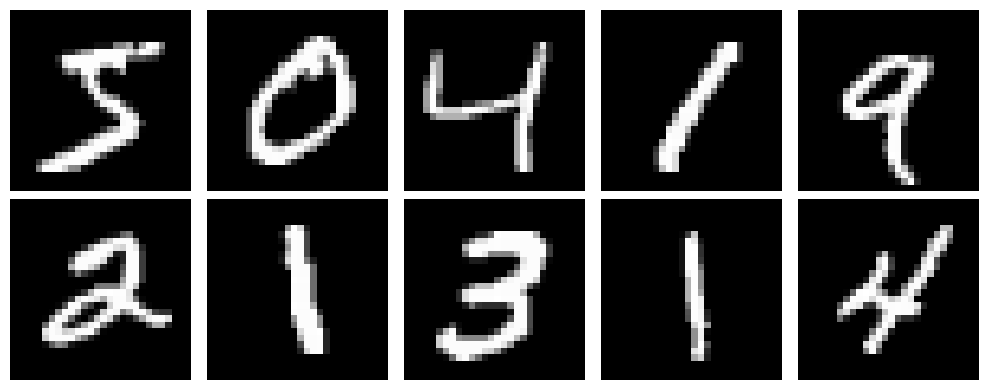

In [3]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (-1,28,28,1))
x_test = np.reshape(x_test, (-1,28,28,1))

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)


In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy Train Shape:", x_train_noisy.shape)

Noisy Train Shape: (60000, 28, 28, 1)


In [6]:
input_img = layers.Input(shape=(28,28,1))

# Encoder
x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

# Decoder
x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = layers.UpSampling2D(
    (2,2)
)(x)

x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = layers.UpSampling2D(
    (2,2)
)(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 425ms/step - loss: 0.1510 - val_loss: 0.1112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 403ms/step - loss: 0.1084 - val_loss: 0.1050
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step - loss: 0.1038 - val_loss: 0.1018
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 396ms/step - loss: 0.1013 - val_loss: 0.0997
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 397ms/step - loss: 0.0997 - val_loss: 0.0990
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 403ms/step - loss: 0.0987 - val_loss: 0.0977
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 402ms/step - loss: 0.0979 - val_loss: 0.0972
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 404ms/step - loss: 0.0972 - val_loss: 0.0963
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 395ms/step - loss: 0.0966 - val_loss: 0.0958
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 399ms/step - loss: 0.0961 - val_loss: 0.0955


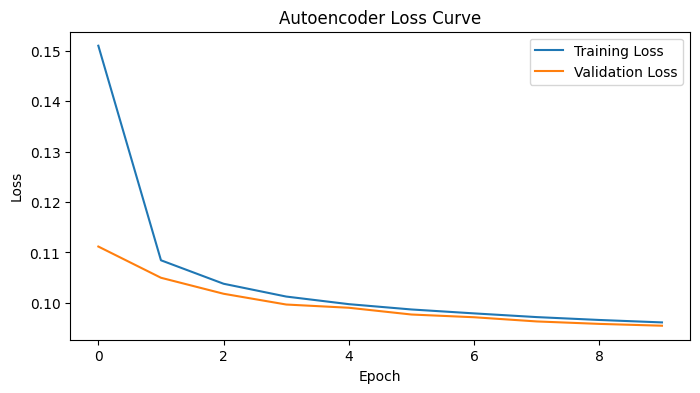

In [8]:

plt.figure(figsize=(8,4))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Autoencoder Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.flatten(),
    decoded_imgs.flatten()
)

print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.010865963995456696


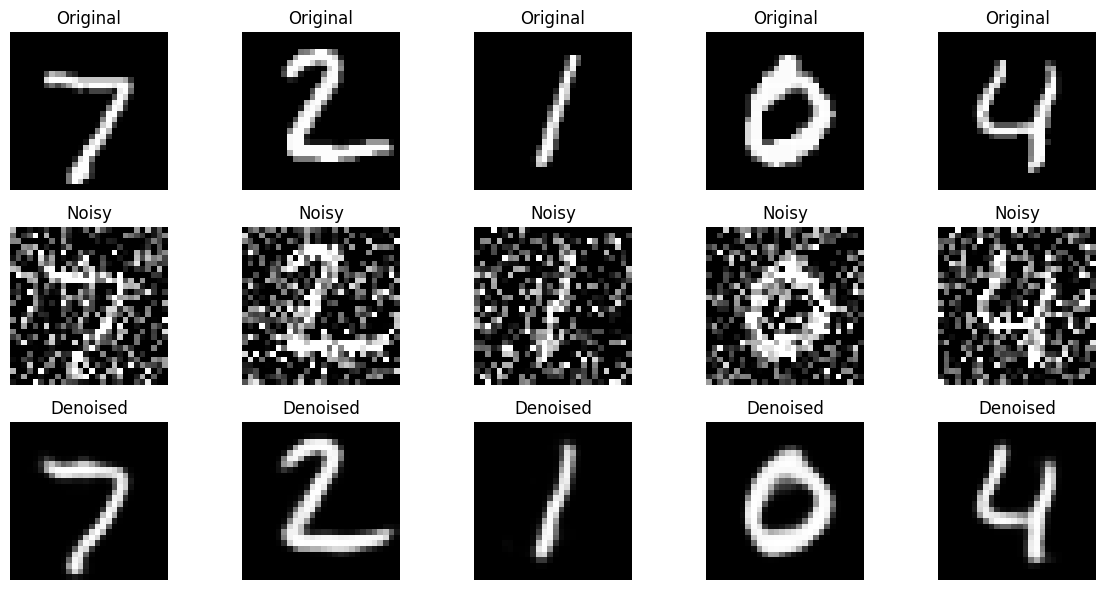

In [11]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()